In [1]:
import pandas as pd

df = pd.read_csv("../data/bpi-challenge-2017/bpi_2017_cleaned.csv")

# convert timestamp
df["time:timestamp"] = pd.to_datetime(
    df["time:timestamp"],
    format="mixed",
    utc=True
)

# sort đúng thứ tự
df = df.sort_values(by=["case:concept:name", "time:timestamp"])

In [2]:
import pm4py

log = pm4py.format_dataframe(
    df,
    case_id='case:concept:name',
    activity_key='concept:name',
    timestamp_key='time:timestamp'
)

In [3]:
import pm4py

net, im, fm = pm4py.discover_petri_net_inductive(log)

KeyboardInterrupt: 

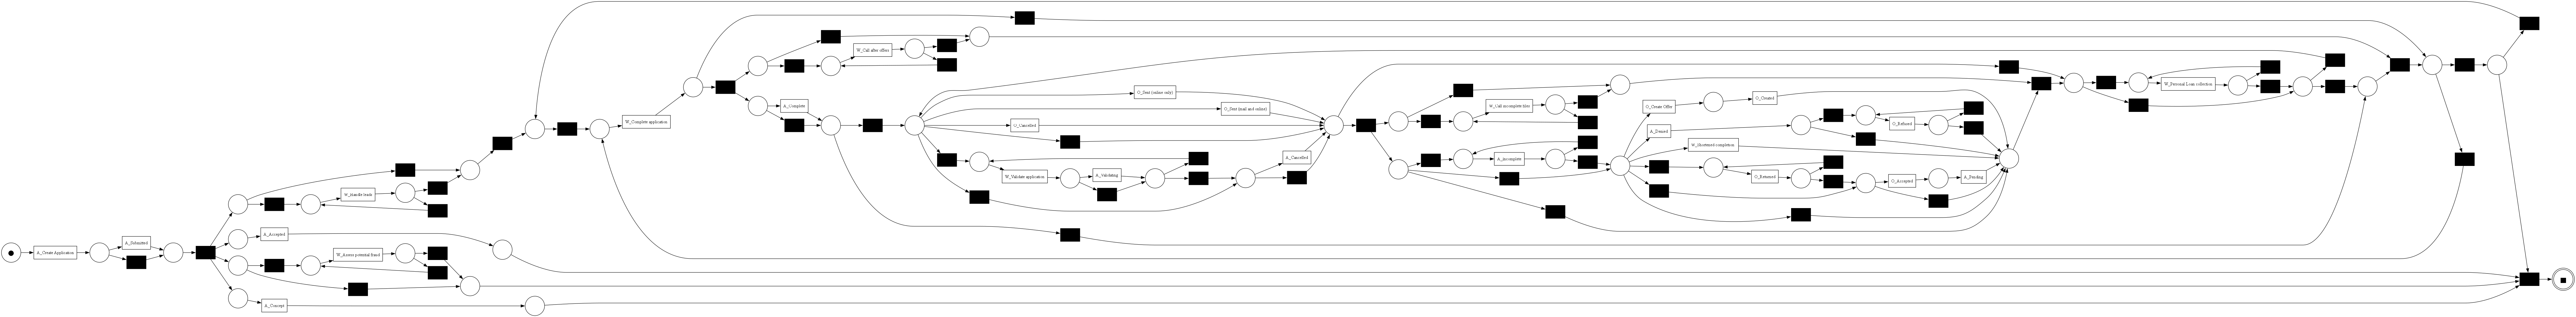

In [ ]:
from pm4py.visualization.petri_net import visualizer as pn_vis

gviz = pn_vis.apply(net, im, fm)
pn_vis.view(gviz)

In [4]:
print("Cases:", df["case:concept:name"].nunique())
print("Events:", len(df))
print("Activities:", df["concept:name"].nunique())

Cases: 31509
Events: 1202267
Activities: 26


In [5]:
import numpy as np

durations = pm4py.get_all_case_durations(log)

print("Mean:", np.mean(durations))
print("Min:", np.min(durations))
print("Max:", np.max(durations))

Mean: 1892125.923069948
Min: 201.062
Max: 24716658.654


In [6]:
variants = pm4py.get_variants(log)

print("Number of variants:", len(variants))

Number of variants: 15930


In [7]:
df["concept:name"].value_counts().head(10)

concept:name
W_Validate application      209496
W_Call after offers         191092
W_Call incomplete files     168529
W_Complete application      148900
W_Handle leads               47264
O_Create Offer               42995
O_Created                    42995
O_Sent (mail and online)     39707
A_Validating                 38816
A_Accepted                   31509
Name: count, dtype: int64

In [ ]:
import pm4py

aligned_traces = pm4py.conformance_diagnostics_alignments(
    log, net, im, fm
)

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
aligning log, completed variants ::  71%|███████▏  | 11385/15930 [10:02:33<9:02:53,  7.17s/it] 

In [ ]:
import pm4py

durations = pm4py.get_all_case_durations(log)

print("Average duration:", sum(durations) / len(durations))

In [ ]:
import pm4py

pm4py.view_performance_spectrum(
    log,
    activities=["A_Submitted", "A_Accepted"]
)

In [ ]:
import pm4py

sna_res = pm4py.discover_handover_of_work_network(log)
pm4py.view_sna(sna_res)

In [ ]:
variants = pm4py.get_variants(log)

print("Number of variants:", len(variants))

In [ ]:
from sklearn.tree import DecisionTreeClassifier

features = df[["CreditScore", "RequestedAmount"]].fillna(0)
target = df["Accepted"].fillna(False)

model = DecisionTreeClassifier()
model.fit(features, target)